In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# This will install the mibian library, which provides options pricing and Greek calculations based on the Black-Scholes-Merton model.
!pip install mibian



  Preparing metadata (setup.py) ... done
  Created wheel for mibian: filename=mibian-0.1.3-py3-none-any.whl size=4024 sha256=463503145d7a3ceab1a613b6492e4fb8ab93c511e1810794e7c85277082019f4
  Stored in directory: /root/.cache/pip/wheels/b2/71/71/a9ff30d4851199bf1efabdda83809623cf181762214ae6b7c7
Successfully built mibian


In [3]:
import numpy as np  # For numerical computations
import matplotlib.pyplot as plt  # For data visualization
from bs4 import BeautifulSoup  # For web scraping and HTML parsing
import pandas as pd  # For data manipulation and analysis
from urllib.request import urlopen, Request  # For making HTTP requests
from urllib.error import HTTPError  # For handling HTTP errors
from nltk.sentiment.vader import SentimentIntensityAnalyzer  # For sentiment analysis
import mibian  # For options pricing and Greek calculations
import os  # For operating system related functionalities


In [4]:
import nltk  # Natural Language Toolkit library for text processing and analysis

nltk.download('vader_lexicon')  # Download the VADER (Valence Aware Dictionary and sEntiment Reasoner) lexicon


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [5]:
# Define the base URL for the Finviz website
web_url = 'https://finviz.com/quote.ashx?t='


In [6]:
# Dictionary to store news tables
news_tables = {}

# List of tickers
tickers = ['AAPL', 'JPM', 'XOM']


In [7]:
for tick in tickers:
    # Construct the URL for the specific ticker
    url = web_url + tick

    # Create a request object with the URL and a User-Agent header
    req = Request(url=url, headers={"User-Agent": "Mozilla/5.0"})

    # Try to open the URL and retrieve the response
    try:
        response = urlopen(req)
        html = BeautifulSoup(response, "html.parser")

        # Find the news table in the HTML
        news_table = html.find(id='news-table')

        # Check if the news table is found
        if news_table is None:
            print(f"Could not find news table for {tick}")
        else:
            # Store the news table in the dictionary using the ticker as the key
            news_tables[tick] = news_table
            print(f"Found news table for {tick}")

    # Handle HTTP errors
    except HTTPError as e:
        print(f"Could not access {url}: {e}")


Found news table for AAPL
Found news table for JPM
Found news table for XOM


In [8]:
news_tables
#from abve line took payload and created an sample.html to understand payload

{'AAPL': <table border="0" cellpadding="1" cellspacing="0" class="fullview-news-outer news-table" data-ticker="AAPL" id="news-table" width="100%">
 <tr class="cursor-pointer has-label" onclick="trackAndOpenNews(event, 'The Wall Street Journal', 'https://finance.yahoo.com/m/48caa81c-3781-32eb-9de2-0d1c06b4a205/berkshire-buys-shares-of.html');">
 <td align="right" width="130">
             Today 05:32PM
         </td>
 <td align="left">
 <div class="news-link-container">
 <div class="news-link-left">
 <a class="tab-link-news" href="https://finance.yahoo.com/m/48caa81c-3781-32eb-9de2-0d1c06b4a205/berkshire-buys-shares-of.html" rel="nofollow" target="_blank">Berkshire Buys Shares of Alphabet and Further Pares Apple Stake</a>
 </div>
 <div class="news-link-right">
 <span>(The Wall Street Journal)</span></div></div></td></tr>
 <tr class="cursor-pointer has-label" onclick="trackAndOpenNews(event, 'Investing.com', 'https://finance.yahoo.com/news/berkshire-hathaway-reveals-4-3-222909470.html');

In [9]:
news_list = []
for file_name, news_table in news_tables.items():
    for i in news_table.findAll('tr'):

        a_tag = i.a # fixed this part - when a is None code breaks
        if a_tag is not None:
            text = a_tag.get_text() # here collecting text from achor tag inside each table data row
            date_scrape = i.td.text.split() # list of date and time or may be list of time
            if len(date_scrape) == 1:  # if list has one element then that is time
                time = date_scrape[0]
            #if list has two elements then  date is first element at index 0 and time is at index 1
            else:
                # here once date is set it will insert for every instance even where there is no date
                date = date_scrape[0]
                time = date_scrape[1]
            tick = file_name
            news_list.append([tick, date, time, text]) # appending data to list
        else:
            # few table data has no anchor tags which means it has no data in it
            # sending them if else loop to skip thoses tags to avoid nan
            print("Skipping row without 'a' tag: ", i)


/tmp/ipython-input-2406678227.py:3: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  for i in news_table.findAll('tr'):


In [10]:
# Create a sentiment analyzer object
vader = SentimentIntensityAnalyzer()

# Define the columns for the news DataFrame
columns = ['ticker', 'date', 'time', 'headline']

# Create a DataFrame to store the news data with the specified columns
news_df = pd.DataFrame(news_list, columns=columns)

# Check for missing values in the DataFrame
news_df.isnull().sum()


,0
ticker,0
date,0
time,0
headline,0


In [11]:
# Calculate sentiment scores for each headline in the news DataFrame
scores = news_df['headline'].apply(vader.polarity_scores).tolist()

# Print the sentiment scores for the first three headlines
print(scores[0:3])


[{'neg': 0.0, 'neu': 0.804, 'pos': 0.196, 'compound': 0.296}, {'neg': 0.196, 'neu': 0.804, 'pos': 0.0, 'compound': -0.296}, {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}]


In [12]:
# Create a DataFrame from the list of sentiment scores
scores_df = pd.DataFrame(scores)

# Join the scores DataFrame with the news DataFrame
news_df = news_df.join(scores_df, rsuffix='_right')

# Display the updated news DataFrame with sentiment scores
news_df


,ticker,date,time,headline,neg,neu,pos,compound
0,AAPL,Today,05:32PM,Berkshire Buys Shares of Alphabet and Further ...,0.000,0.804,0.196,0.2960
1,AAPL,Today,05:29PM,Berkshire Hathaway reveals $4.3 billion stake ...,0.196,0.804,0.000,-0.2960
2,AAPL,Today,05:06PM,ChatGPT: Everything you need to know about the...,0.000,1.000,0.000,0.0000
3,AAPL,Today,05:01PM,Warren Buffett's Strategic Moves: Apple Inc. S...,0.000,1.000,0.000,0.0000
4,AAPL,Today,04:47PM,Apple's China business hasn't 'turned the corn...,0.154,0.846,0.000,-0.2924
...,...,...,...,...,...,...,...,...
295,XOM,Oct-30-25,08:00PM,Supermajors Bet Big on Long-Term Oil Demand,0.200,0.800,0.000,-0.1280
296,XOM,Oct-30-25,07:00PM,"Exxon & Chevron earnings, Fed, YouTube-Disney:...",0.000,1.000,0.000,0.0000
297,XOM,Oct-30-25,06:00PM,Analysts Eye Big Oil's Spending and Acquisitio...,0.000,1.000,0.000,0.0000
298,XOM,Oct-30-25,04:41PM,"Earnings live: Amazon stock soars, Apple CEO p...",0.000,0.747,0.253,0.5267


In [13]:
from datetime import datetime

# Replace 'Today' with the current date
news_df['date'] = news_df['date'].replace({'Today': datetime.now().date()})

# Convert the 'date' column to datetime
news_df['date'] = pd.to_datetime(news_df['date']).dt.date

# Remove rows where date conversion failed
news_df = news_df.dropna(subset=['date'])

# Print the updated 'date' column
print(news_df['date'])


0      2025-11-14
1      2025-11-14
2      2025-11-14
3      2025-11-14
4      2025-11-14
          ...    
295    2025-10-30
296    2025-10-30
297    2025-10-30
298    2025-10-30
299    2025-10-30
Name: date, Length: 300, dtype: object


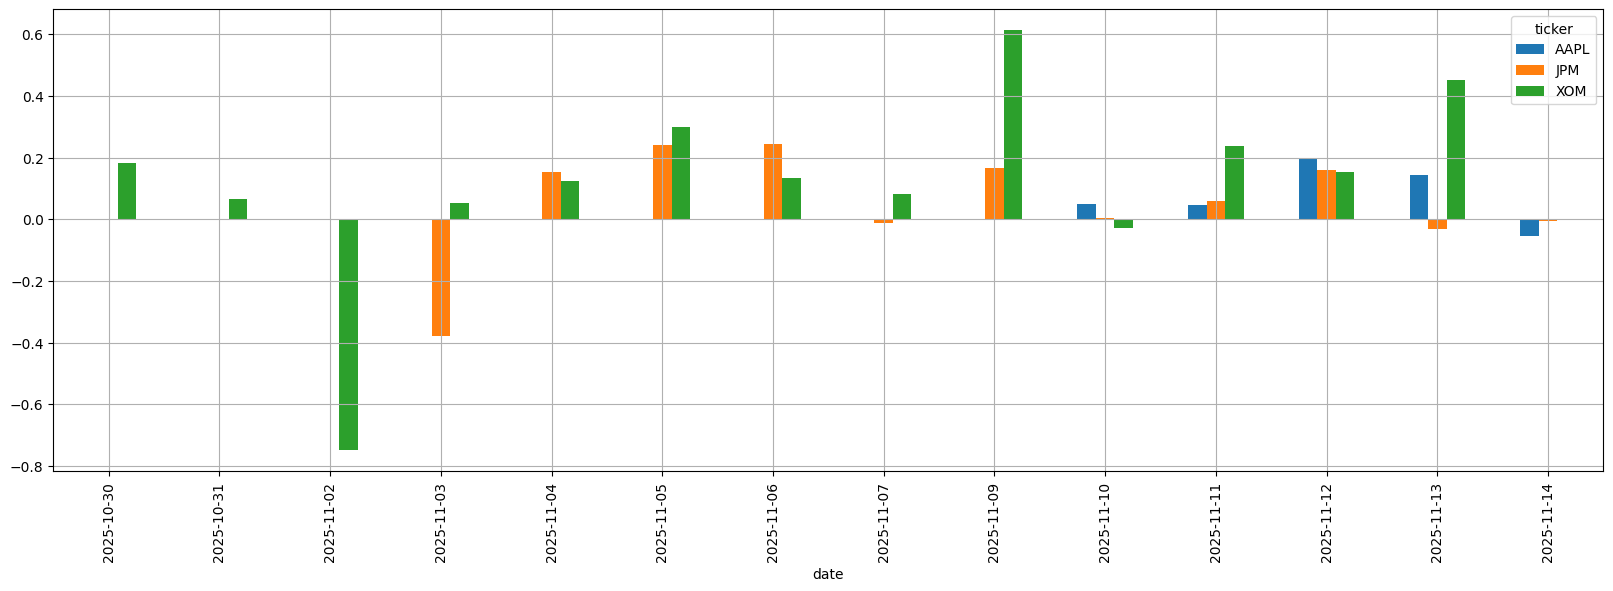

In [14]:
# Set the figure size for the plot
plt.rcParams['figure.figsize'] = [20, 6]

# Select the desired columns for calculating mean scores
columns = ['ticker', 'date', 'neg', 'neu', 'pos', 'compound']

# Calculate the mean scores by grouping the data by ticker and date
mean_scores = news_df[columns].groupby(['ticker', 'date']).mean().reset_index()

# Pivot the mean_scores DataFrame to have dates as rows and tickers as columns, with compound scores as values
mean_scores = mean_scores.pivot(index='date', columns='ticker', values='compound')

# Plot the mean scores as a bar plot
mean_scores.plot(kind='bar')

# Add grid lines to the plot
plt.grid()

# Display the plot
plt.show()

